In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/DONNEES DE BASE/Anciennes_colonnes_&_Nouvelles_Colonnes.xlsx")
df.head()

,ident,Type_de_centre,Regime,Persojuri,Decla24,gctax (groupe de compte de gestion des contribuables),Conformité de déclaration de marchés en MNDNPCMD9,ConfmpMNDNPC,ConfmpMNDMD,ConfmpMNDMND,...,NBMP,Nombre_dactivités_2021,Nombre_dactivtés_2022,Nombre_dactivtés_2023,Nombre_dactivités_20212024,SBTP,SERM,SFBME,SPSOE,STLM
0,150.0,CDI,REEL,Physique,Oui,Grands comptes,MD,MD,MD,MD,...,2.0,0.0,7.0,11.0,18.0,0.0,1.0,0.0,0.0,0.0
1,276.0,CDI,REEL,Physique,Oui,Grands comptes,MD,MD,MD,MD,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,438.0,CDI,REEL,Morale,Oui,Grands comptes,MD,MD,MD,MND,...,3.0,0.0,1.0,2.0,3.0,0.0,1.0,0.0,0.0,0.0
3,461.0,CDI,REEL,Physique,Oui,Grands comptes,MND,MND,MND,MD,...,3.0,12.0,12.0,2.0,26.0,1.0,0.0,0.0,0.0,0.0
4,558.0,CDI,REEL,Physique,Oui,Grands comptes,MND,NPC,MD,MND,...,3.0,5.0,1.0,2.0,8.0,1.0,0.0,0.0,0.0,0.0


In [3]:
df.columns

Index(['ident', 'Type_de_centre', 'Regime', 'Persojuri', 'Decla24',
       'gctax (groupe de compte de gestion des contribuables)',
       'Conformité de déclaration de marchés en MNDNPCMD9', 'ConfmpMNDNPC',
       'ConfmpMNDMD', 'ConfmpMNDMND', 'ConfmpMND3', 'MinCAOui9', 'MinCA2Non',
       'MinCA2Oui', 'MinCA22', 'MinCA23', 'MinCA24', 'MinTotale', 'EcCAMP',
       'Ecart24(Target)', 'Nbprestation_marchés', 'Typedemarché',
       'Nombre_dactivtés_2024', 'TypeNIU', 'DElCA', 'RAS', 'TxdDSFMp',
       'Ecart19', 'Ecart20', 'Ecart21', 'Ecart22', 'Ecart23', 'SomCA', 'CA19',
       'CA20', 'CA21', 'CA22', 'CA23', 'CA24', 'CumCA24', 'DElCA.1', 'SomMP',
       'MontantMP19', 'MontantMP20', 'MontantMP21', 'MontantMP22',
       'MontantMP23', 'MontantMP24', 'DSF19', 'DSF20', 'DSF21', 'DSF22',
       'DSF23', 'DSF24', 'MP19', 'MP20', 'MP21', 'MP22', 'MP23', 'MP24',
       'Type de déclarant des MP dans les DSF', 'Delta19', 'Delta20',
       'Delta21', 'Delta22', 'Delta23', 'Delta24', 'Txactif',

## DELTCA
- On a 4107 valeurs égales à 0
- On a 1057 valeurs inférieures à 0
- On a 6634 > 0

<Axes: xlabel='Ecart24(Target)'>

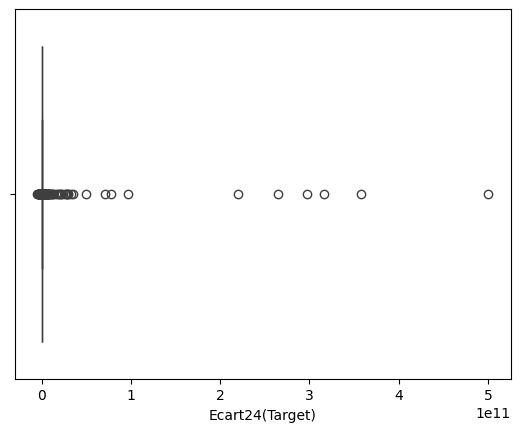

In [4]:
sns.boxplot(data=df, x=df['Ecart24(Target)'])

## clustering pour déterminer le nombre de segments optimal

In [25]:
from sklearn.cluster import KMeans
import numpy as np

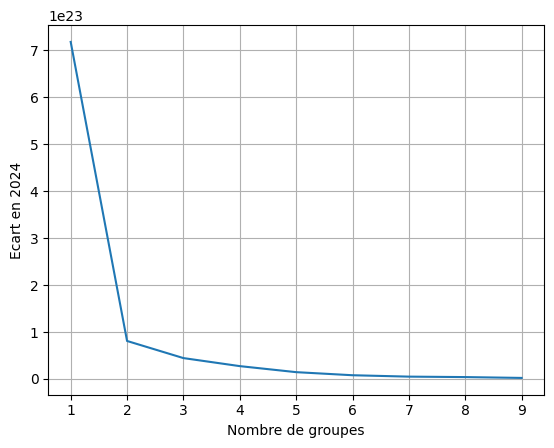

In [27]:
nb = range(1, 10)
k_inertia = []

for c in nb:
    model = KMeans(n_clusters=c).fit(pd.DataFrame(df[df["Ecart24(Target)"]>100000]["Ecart24(Target)"]).dropna())
    k_inertia.append(model.inertia_)

plt.plot(nb, k_inertia)
plt.grid()
plt.xlabel("Nombre de groupes")
plt.ylabel("Ecart en 2024")
plt.savefig("Resultats_segmentation.png")
plt.show()

In [42]:
# Quartiles de la variable
quartiles = df[df["Ecart24(Target)"]>100000]['Ecart24(Target)'].quantile([0.2, 0.4, 0.6, 0.7, 0.8])
quartiles

0.2     11618581.0
0.4     25612846.0
0.6     46437364.0
0.7     66467271.0
0.8    105304724.0
Name: Ecart24(Target), dtype: float64

In [43]:
cl = df[df["Ecart24(Target)"]>100000][["Ecart24(Target)"]].dropna()

kmeans = KMeans(n_clusters=2, random_state=2)
cl['cluster'] = kmeans.fit_predict(cl[['Ecart24(Target)']])

In [44]:
# regroupement par cluster
# Min et max par cluster
resultat = cl.groupby("cluster")["Ecart24(Target)"].agg(["min", "max"]).reset_index()

resultat

,cluster,min,max
0,0,1.217592e+05,9.656233e+10
1,1,2.198432e+11,5.005424e+11
